In [2]:
### Build a basic chat bot with LangGraph(Graph API)

In [3]:
from typing import Annotated

from langgraph.graph import START, END,StateGraph

from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


In [4]:
class State(TypedDict):
    #Messages have the type list. The 'add_messages'  funtion in 
    # the annotation defines how this state key should be updated
    #(in this case it appends the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv

load_dotenv()


True

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model


llm = ChatGroq(model="llama-3.1-8b-instant")

In [8]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002813420DBB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002813436E7B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
anotherway = init_chat_model("groq:llama-3.1-8b-instant")
anotherway

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002813436F020>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002813436F4A0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
##Node funtionality 

def chatBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)

## defining a node here 
graph_builder.add_node("myBot1",chatBot)

## defining edge from start to myBot1
graph_builder.add_edge(START,"myBot1")

## defining edge from myBot1 to End
graph_builder.add_edge("myBot1",END)


## compile the Graph
graph = graph_builder.compile()


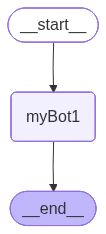

In [12]:
##Visualize the Graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
 response = graph.invoke({"messages":"Hello, how are you?"})

In [14]:
response["messages"][-1].content

"Hello. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?"

In [15]:
## Now We will make a bot simple one

from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represent

In [16]:
## we will create custom function here 

def multyply(a:int,b:int)-> int :
    """ Multiply a and b

    Args:
        a (int): first number
        b (int): second number

    returns:
        int: output int
    """
    return a*b


In [17]:
tools = [tool, multyply]
print(type(multyply))
print(type(tool))

<class 'function'>
<class 'langchain_tavily.tavily_search.TavilySearch'>


In [18]:
llm_with_tool = llm.bind_tools(tools)



In [19]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002813420DBB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002813436E7B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine

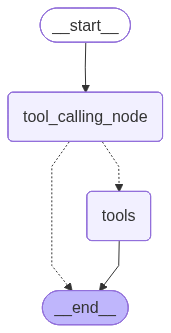

In [20]:
## We will create State Graph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
 
## create node definations 

def tool_calling_node(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## create node first

builder = StateGraph(State)
builder.add_node("tool_calling_node",tool_calling_node)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_node")
builder.add_conditional_edges("tool_calling_node",
                              #this is tool condition in which is the result is tool call it will route to tool node otherwise it will route to end node
                              tools_condition)
builder.add_edge("tools",END)   

## compile the graph

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response = graph.invoke({"messages":"Hey what is the recent ai news"})

In [22]:
response["messages"][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tradingview.com/news/reuters.com,2026-06-15:newsml_XB0J3I2J1:0-table-ai-2026-27-parent-forecast/", "title": "TABLE-Ai -2026/27 parent forecast - TradingView", "score": 0.59061456, "published_date": "Mon, 15 Jun 2026 06:30:33 GMT", "content": "# TABLE-Ai -2026/27 parent forecast — TradingView News. *   /TABLE-Ai -2026/27 parent forecast. Image 2: ReutersImage 3: Reuters. Click For Restrictions - http://about.reuters.com/fulllegal.asp. Sign in or create a free account to read this news. ## AI chart. ## Latest news. ## More news from Reuters. * Image 5 * Image 6 * Image 7 Dec 22, 2025 Reuters Mergers and acquisitionsDec 22, 2025 Reuters KALENDER-Termine Politik/Vermischtes bis 28. Dezember* Image 8 Dec 22, 2025 Reuters Australia\'s FlexiRoam surge on Generali dealDec 22, 2025 Reuters Malaysia\'s ex-PM Najib to face two key court rulings in 1MDB sagaDec 21, 2025 Reuters 

In [23]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3gq39h40z)
 Call ID: 3gq39h40z
  Args:
    query: recent ai news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tradingview.com/news/reuters.com,2026-06-15:newsml_XB0J3I2J1:0-table-ai-2026-27-parent-forecast/", "title": "TABLE-Ai -2026/27 parent forecast - TradingView", "score": 0.59061456, "published_date": "Mon, 15 Jun 2026 06:30:33 GMT", "content": "# TABLE-Ai -2026/27 parent forecast — TradingView News. *   /TABLE-Ai -2026/27 parent forecast. Image 2: ReutersImage 3: Reuters. Click For Restrictions - http://about.reuters.com/fulllegal.asp. Sign in or create a free account to 

In [24]:
response = graph.invoke({"messages":"Hey what is 4589*9439"})

In [25]:
response["messages"][-1].content

'43315571'

In [26]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey what is 4589*9439
================================== Ai Message ==================================
Tool Calls:
  multyply (3zx8vsdr8)
 Call ID: 3zx8vsdr8
  Args:
    a: 4589
    b: 9439
================================= Tool Message =================================
Name: multyply

43315571


In [27]:
response = graph.invoke({"messages":"what is 78 multipy 10 and then multiply wihth 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 78 multipy 10 and then multiply wihth 2
================================== Ai Message ==================================
Tool Calls:
  multyply (c7812jyxs)
 Call ID: c7812jyxs
  Args:
    a: 78
    b: 10
================================= Tool Message =================================
Name: multyply

780


In [28]:
response = graph.invoke({"messages":"what is 78 multipy 10 and then multiply wihth 2 and what is the sentiment of stock market"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 78 multipy 10 and then multiply wihth 2 and what is the sentiment of stock market
================================== Ai Message ==================================
Tool Calls:
  multyply (vc985hk03)
 Call ID: vc985hk03
  Args:
    a: 78
    b: 10
  multyply (re4z1hdtb)
 Call ID: re4z1hdtb
  Args:
    a: 780
    b: 2
================================= Tool Message =================================
Name: multyply

780
================================= Tool Message =================================
Name: multyply

1560


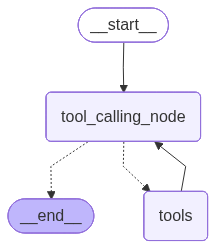

In [31]:
## We will create State Graph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
 
## create node definations 

def tool_calling_node(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## create node first

builder = StateGraph(State)
builder.add_node("tool_calling_node",tool_calling_node)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_node")
builder.add_conditional_edges("tool_calling_node",
                              #this is tool condition in which is the result is tool call it will route to tool node otherwise it will route to end node
                              tools_condition)
builder.add_edge("tools","tool_calling_node")
builder.add_edge("tool_calling_node",END)   

## compile the graph

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
response = graph.invoke({"messages":"what is 78 multipy 10 and then multiply wihth 2 and then tell me what is the latest price of gold"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 78 multipy 10 and then multiply wihth 2 and then tell me what is the latest price of gold
================================== Ai Message ==================================
Tool Calls:
  multyply (rtrn22rvg)
 Call ID: rtrn22rvg
  Args:
    a: 78
    b: 10
  multyply (mq9bxpsv6)
 Call ID: mq9bxpsv6
  Args:
    a: 780
    b: 2
  tavily_search (yx5rhzb79)
 Call ID: yx5rhzb79
  Args:
    query: latest gold price
    search_depth: advanced
    topic: finance
================================= Tool Message =================================
Name: multyply

780
================================= Tool Message =================================
Name: multyply

1560
================================= Tool Message =================================
Name: tavily_search

{"query": "latest gold price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/advisor/investi

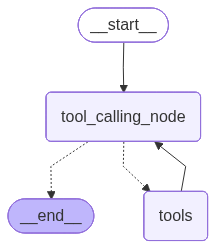

In [33]:
## now we will add memory you so that agent can keep track of conversation and tools calls


## We will create State Graph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver#import the memory saver checkpointer

memory = MemorySaver()



## create node definations 

def tool_calling_node(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## create node first

builder = StateGraph(State)
builder.add_node("tool_calling_node",tool_calling_node)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_node")
builder.add_conditional_edges("tool_calling_node",
                              #this is tool condition in which is the result is tool call it will route to tool node otherwise it will route to end node
                              tools_condition)
builder.add_edge("tools","tool_calling_node")
builder.add_edge("tool_calling_node",END)   

## compile the graph

graph = builder.compile(checkpointer=memory)# pass the memory checkpointer to compile the graph

display(Image(graph.get_graph().draw_mermaid_png()))


In [34]:
config = {"configurable":{"thread_id":"1"}}

In [35]:
response = graph.invoke({"messages":"Hi my name is shiv"},config=config)

for r in response["messages"]:
    r.pretty_print()

================================ Human Message =================================

Hi my name is shiv
================================== Ai Message ==================================

Nice to meet you, Shiv. Is there anything I can help you with today?


In [36]:
response = graph.invoke({"messages":"who am i"},config=config)

for r in response["messages"]:
    r.pretty_print()

================================ Human Message =================================

Hi my name is shiv
================================== Ai Message ==================================

Nice to meet you, Shiv. Is there anything I can help you with today?
================================ Human Message =================================

who am i
================================== Ai Message ==================================

Your name is Shiv.


In [37]:
## Streamings

#Stram_mode = Updates what it does that it will only give the updates not the full message list and in values it will give the full message list in each stream
config = {"configurable":{"thread_id":"2"}}

chunk = graph.stream({"messages":"Hi my name is shiv"},config,stream_mode="updates")#using stram mode updates

for c in chunk:
    print(c)


{'tool_calling_node': {'messages': [AIMessage(content='Nice to meet you, Shiv. Is there anything I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 1755, 'total_tokens': 1773, 'completion_time': 0.025396958, 'completion_tokens_details': None, 'prompt_time': 0.111093799, 'prompt_tokens_details': None, 'queue_time': 0.050336621, 'total_time': 0.136490757}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edb42-cf64-70d3-86c9-fc2ccc8f7eb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 18, 'total_tokens': 1773})]}}


In [40]:
## Streamings


config = {"configurable":{"thread_id":"2"}}

chunk = graph.stream({"messages":"Hi my name is shiv"},config,stream_mode="values")#using stram mode updates

for c in chunk:
    print(c)


{'messages': [HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='7fbd8ca5-acee-4d7d-91be-e505a61c5d0e'), AIMessage(content='Nice to meet you, Shiv. Is there anything I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 1755, 'total_tokens': 1773, 'completion_time': 0.025396958, 'completion_tokens_details': None, 'prompt_time': 0.111093799, 'prompt_tokens_details': None, 'queue_time': 0.050336621, 'total_time': 0.136490757}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edb42-cf64-70d3-86c9-fc2ccc8f7eb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 18, 'total_tokens': 1773}), HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='dc585d82-d030-4d

In [41]:
chunk = graph.stream({"messages":"Hi love varaa"},config,stream_mode="values")#using stram mode updates

for c in chunk:
    print(c)


{'messages': [HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='7fbd8ca5-acee-4d7d-91be-e505a61c5d0e'), AIMessage(content='Nice to meet you, Shiv. Is there anything I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 1755, 'total_tokens': 1773, 'completion_time': 0.025396958, 'completion_tokens_details': None, 'prompt_time': 0.111093799, 'prompt_tokens_details': None, 'queue_time': 0.050336621, 'total_time': 0.136490757}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edb42-cf64-70d3-86c9-fc2ccc8f7eb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 18, 'total_tokens': 1773}), HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='dc585d82-d030-4d

In [ ]:
chunk = graph.stream({"messages":"i love varaa i mean she is my wife"},config,stream_mode="values")#using stram mode updates

for c in chunk:
    print(c)


{'messages': [HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='a083bba5-e91e-42e4-b1d1-a514d38e9716'), AIMessage(content="Hello Shiv, it's nice to meet you. Is there something I can help you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1755, 'total_tokens': 1775, 'completion_time': 0.031211123, 'completion_tokens_details': None, 'prompt_time': 0.178092735, 'prompt_tokens_details': None, 'queue_time': 0.053820475, 'total_time': 0.209303858}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed68e-aed2-7df0-9fa1-36fb3ae653c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 20, 'total_tokens': 1775}), HumanMessage(content='Hi my name is shiv', additional_kwargs={}, response_metadata={}, id='f9d56ebd-4

In [43]:
chunk = graph.stream({"messages":"marrying her will be good naa"},config,stream_mode="updates")#using stram mode updates

for c in chunk:
    print(c)


{'tool_calling_node': {'messages': [AIMessage(content="It seems like you're excited about the idea of marrying Love Varaa. However, I don't know much about your relationship or your personal life. If you're considering marriage, I can offer some general advice or suggestions if you'd like.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 1972, 'total_tokens': 2023, 'completion_time': 0.080998289, 'completion_tokens_details': None, 'prompt_time': 0.14613478, 'prompt_tokens_details': None, 'queue_time': 0.05213869, 'total_time': 0.227133069}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019edb48-640d-7aa2-b5e2-25d1f53ca623-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1972, 'output_tokens': 51, 'total_tokens': 2023})]}}
